<a href="https://colab.research.google.com/github/rnkarmakar/rnkarmakar.github.io/blob/main/AIST_GNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup, Imports and Data Preparation

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from scipy.sparse import csr_matrix, diags, eye
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Config
n_nodes, n_features = 2000, 128
true_prior, observe_ratio = 0.3, 0.02
hidden_dim, lr = 64, 0.01
em_iters, epochs_per_iter, lbp_iters = 5, 50, 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eps_G = 0.8     # > 0.5 means graph homophily
eps_SD = 0.99   # 1.0 only if SD labels are 100% correct

In [ ]:
# Synthetic Data Generation
np.random.seed(42)
torch.manual_seed(42)
X_np = np.random.randn(n_nodes, n_features)
Y_np = np.random.choice([0, 1], size=n_nodes, p=[1-true_prior, true_prior])

# Homophily-based Adjacency Matrix
A_np = np.zeros((n_nodes, n_nodes))
for i in range(n_nodes):
  for j in range(i + 1, n_nodes):
    prob = 0.05 if Y_np[i] == Y_np[j] else 0.01
    if np.random.rand() < prob:
      A_np[i, j] = A_np[j, i] = 1
A_sparse = csr_matrix(A_np)

# Convert 0/1 labels to -1/+1 labels for SD construction
Y_pm = 2 * Y_np - 1

# Positive orientation anchors A_+
is_true_pos = (Y_np == 1)
is_observed_anchor = is_true_pos & (np.random.rand(n_nodes) < observe_ratio)
A_pos_idx = np.where(is_observed_anchor)[0]

# Synthetic SD pair set Q
m_Q = 5 * n_nodes
Q_set = set()

while len(Q_set) < m_Q:
  i, j = np.random.randint(0, n_nodes, size=2)
  if i != j:
    Q_set.add(tuple(sorted((i, j))))

Q_pairs = np.array(list(Q_set), dtype=np.int64)

# SD labels: S_ij = Y_i Y_j
S_pairs = Y_pm[Q_pairs[:, 0]] * Y_pm[Q_pairs[:, 1]]

# Normalize Adjacency for GCN
A_tilde = A_sparse + eye(n_nodes)
degree = np.array(A_tilde.sum(axis=1)).flatten()
D_inv_sqrt = diags(np.power(degree, -0.5))
A_norm_sparse = D_inv_sqrt.dot(A_tilde).dot(D_inv_sqrt).tocoo()

# Convert to Tensors
X_tensor = torch.FloatTensor(X_np).to(device)
indices = torch.LongTensor(np.vstack((A_norm_sparse.row, A_norm_sparse.col))).to(device)
values = torch.FloatTensor(A_norm_sparse.data).to(device)
A_norm = torch.sparse_coo_tensor(indices, values, torch.Size(A_norm_sparse.shape)).to(device)
A_pos_idx_tensor = torch.LongTensor(A_pos_idx).to(device)

all_idx = np.arange(n_nodes)
unanchored_idx = np.setdiff1d(all_idx, A_pos_idx)
unanchored_idx_tensor = torch.LongTensor(unanchored_idx).to(device)


## Model Definition and LBP

In [ ]:

class GCNClassifier(nn.Module):
  def __init__(self, in_features, hidden_dim):
    super(GCNClassifier, self).__init__()
    self.W1 = nn.Linear(in_features, hidden_dim)
    self.W2 = nn.Linear(hidden_dim, 1)

  def forward(self, X, A):
    H1 = F.relu(torch.spmm(A, self.W1(X)))
    logits = torch.spmm(A, self.W2(H1))
    return torch.sigmoid(logits).squeeze()

def build_sd_factor_graph(A_sparse, Q_pairs, S_pairs, eps_G=0.8, eps_SD=0.99):
  """
  Returns:
    neighbours[i] = list of (j, psi_ij)
  """
  states = np.array([-1, +1])

  def graph_potential():
    psi = np.zeros((2, 2), dtype=np.float64)
    for a, u in enumerate(states):
      for b, v in enumerate(states):
        psi[a, b] = eps_G if u == v else (1 - eps_G)
    return psi

  def sd_potential(Sij):
    psi = np.zeros((2, 2), dtype=np.float64)
    for a, u in enumerate(states):
      for b, v in enumerate(states):
        psi[a, b] = eps_SD if Sij * u == v else (1 - eps_SD)
    return psi

  factors = {}

  # Add graph-edge factors from E
  A_coo = A_sparse.tocoo()
  psi_G = graph_potential()

  for i, j in zip(A_coo.row, A_coo.col):
    if i < j:
      factors[(i, j)] = factors.get((i, j), np.ones((2, 2))) * psi_G

  # Add SD-pair factors from Q
  for (i, j), Sij in zip(Q_pairs, S_pairs):
    i, j = int(i), int(j)
    if i > j:
      i, j = j, i
    factors[(i,j)] = factors.get((i, j), np.ones((2, 2))) * sd_potential(int(Sij))

  neighbours = [[] for _ in range(n_nodes)]

  for (i, j), psi in factors.items():
    neighbours[i].append((j, psi))
    neighbours[j].append((i, psi.T))

  return neighbours

def loopy_belief_propagation_sd(neighbours, prior, A_pos_idx, n_nodes,
                               max_iter=5, eps=1e-12):
  # Node potentials phi_i
  phi = np.zeros((n_nodes, 2), dtype=np.float64)
  phi[:, 0] = 1.0 - prior
  phi[:, 1] = prior

  # Positive anchors: Z_i = +1
  phi[A_pos_idx, 0] = 0.0
  phi[A_pos_idx, 1] = 1.0

  # Initialize directed messages uniformly
  messages = {}
  for i in range(n_nodes):
    for j, _ in neighbours[i]:
      messages[(i, j)] = np.ones(2, dtype=np.float64) / 2.0

  for _ in tqdm(range(max_iter), desc="LBP Iterations", leave=False):
      new_messages = {}

      for i in range(n_nodes):
          for j, psi_ij in neighbours[i]:

              incoming_product = phi[i].copy()

              for k, _ in neighbours[i]:
                  if k != j:
                      incoming_product *= messages[(k, i)]

              # m_{i -> j}(v) ∝ sum_u phi_i(u) psi_ij(u,v)
              msg = incoming_product @ psi_ij
              msg = msg / (msg.sum() + eps)

              new_messages[(i, j)] = msg

      messages = new_messages

  # Compute beliefs
  B = np.zeros((n_nodes, 2), dtype=np.float64)

  for i in range(n_nodes):
    belief = phi[i].copy()

    for k, _ in neighbours[i]:
      belief *= messages[(k, i)]

    belief = belief / (belief.sum() + eps)
    B[i] = belief

  # Re-impose anchors exactly
  B[A_pos_idx, 0] = 0.0
  B[A_pos_idx, 1] = 1.0

  return torch.FloatTensor(B)



## Iterative Risk Minimization

In [ ]:
model = GCNClassifier(n_features, hidden_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

estimated_prior = 0.1
all_losses = []

neighbours = build_sd_factor_graph(A_sparse, Q_pairs, S_pairs,
                                   eps_G=eps_G, eps_SD=eps_SD)

print("Starting Iterative Risk Minimization... ")
for em_step in tqdm(range(em_iters), desc="Iterative Risk Minimization (outer)"):

  # E-Step
  B = loopy_belief_propagation_sd(neighbours=neighbours, prior=estimated_prior,
                                  A_pos_idx=A_pos_idx, n_nodes=n_nodes,
                                  max_iter=lbp_iters).to(device)

  # M-Step
  model.train()
  loop = tqdm(range(epochs_per_iter), desc=f"Min. Iter {em_step+1}/{em_iters}"
              , leave=False)
  for epoch in loop:
    optimizer.zero_grad()
    preds = model(X_tensor, A_norm)

    loss = -torch.mean(
        B[:, 1] * torch.log(preds + 1e-9) +
        B[:, 0] * torch.log(1.0 - preds + 1e-9)
    )
    loss.backward()
    optimizer.step()

    # Track the loss value
    all_losses.append(loss.item())
    loop.set_postfix(Loss=f"{loss.item():.4f}")

  # Prior Update
  model.eval()
  with torch.no_grad():
    final_preds = model(X_tensor, A_norm)
    predicted_pos_U = (final_preds[unanchored_idx_tensor] > 0.5).float().mean().item()
    estimated_prior = 0.5 * estimated_prior + 0.5 * predicted_pos_U

  print(f"EM Step {em_step+1} | Prior: {estimated_prior:.4f} | Final Loss: {loss.item():.4f}")



Starting Iterative Risk Minimization... 


Iterative Risk Minimization (outer):   0%|          | 0/5 [00:00<?, ?it/s]

LBP Iterations:   0%|          | 0/5 [00:00<?, ?it/s]

Min. Iter 1/5:   0%|          | 0/50 [00:00<?, ?it/s]

EM Step 1 | Prior: 0.5500 | Final Loss: 0.0000


...

Min. Iter 4/5:   0%|          | 0/50 [00:00<?, ?it/s]

EM Step 4 | Prior: 0.9437 | Final Loss: 0.0000


LBP Iterations:   0%|          | 0/5 [00:00<?, ?it/s]

Min. Iter 5/5:   0%|          | 0/50 [00:00<?, ?it/s]

EM Step 5 | Prior: 0.9719 | Final Loss: 0.0000


## Plots

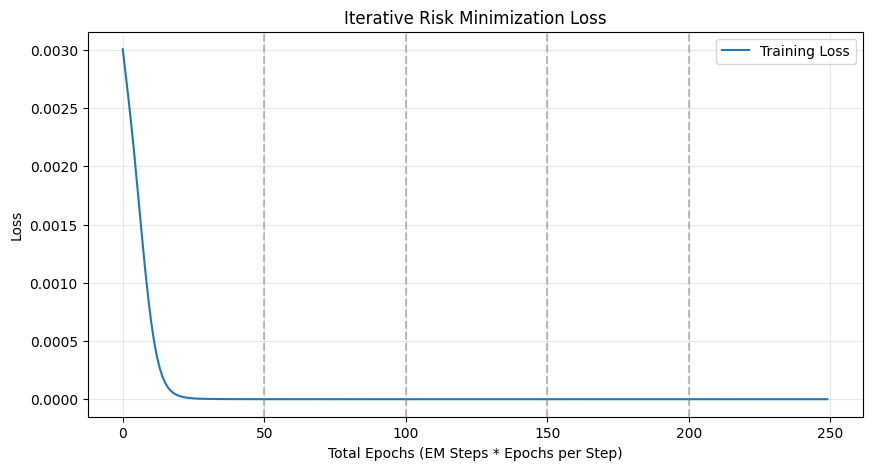

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(all_losses, label='Training Loss', color='tab:blue')

# Add verticel lines to indicate where a new EM step started
for i in range(1, em_iters):
  plt.axvline(x=i * epochs_per_iter, color='gray', linestyle='--', alpha=0.5)

plt.title('Iterative Risk Minimization Loss')
plt.xlabel('Total Epochs (EM Steps * Epochs per Step)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Evaluation

In [ ]:
model.eval()

with torch.no_grad():
    test_preds_prob = model(X_tensor, A_norm)[unanchored_idx_tensor].cpu().numpy()
    test_preds_class = (test_preds_prob > 0.5).astype(int)
    test_true = Y_np[unanchored_idx]

f1 = f1_score(test_true, test_preds_class)
prec = precision_score(test_true, test_preds_class)
rec = recall_score(test_true, test_preds_class)

print("==============================")
print("Evaluation on Unlabeled Nodes")
print("==============================")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"True Prior: {true_prior:.4f} | Final Estimated Prior: {estimated_prior:.4f}")

Evaluation on Unlabeled Nodes
F1 Score:  0.4643
Precision: 0.3024
Recall:    1.0000
True Prior: 0.3000 | Final Estimated Prior: 0.9719


## Evaluation if A_pos_idx = ɸ